# TensorFlow를 활용한 로지스틱 회귀 실습

이 노트북에서는 TensorFlow를 사용하여 간단한 로지스틱 회귀문제를 풀어봅니다.
여기서는 iris 데이터셋을 사용하여 꽃의 종류를 분류하는 예제를 다룹니다.

## 주요 단계
1. 데이터 불러오기 및 전처리
2. 모델 정의 (Dense Layer)
3. 손실 함수 및 최적화 방법 설정
4. 학습 진행 및 시각화


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
print(tf.__version__)

I0000 00:00:1789966388.950228    2443 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1789966390.421138    2443 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


2.21.0


## 1. 데이터 불러오기 및 전처리

In [2]:
# ----------------------
# 1. 데이터 불러오기
# ----------------------
iris = load_iris()
X = iris.data[:, :2]  # 꽃받침 길이, 꽃받침 너비 (2개 feature만 사용해서 시각화 쉽게)
y = (iris.target == 0).astype(np.float32)  # Setosa = 1, Others = 0

print("X shape:", X.shape, "y shape:", y.shape)

# train/test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 표준화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X shape: (150, 2) y shape: (150,)


## 2. 모델 정의

In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

## 3. 모델 컴파일
- 손실 함수: MSE (Mean Squared Error)
- 최적화 방법: SGD (Stochastic Gradient Descent)

In [4]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              loss="binary_crossentropy",
              metrics=["accuracy"])

## 4. 모델 학습

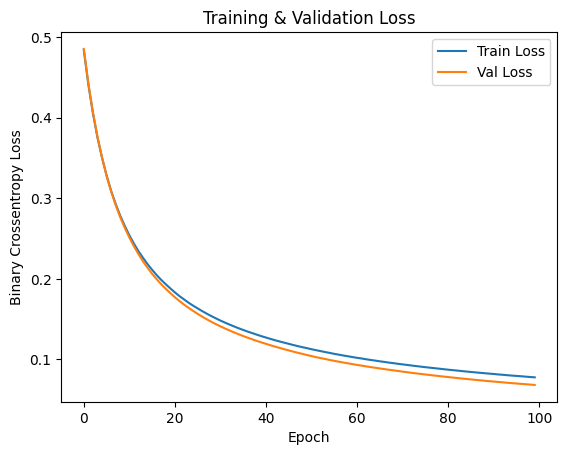

In [5]:
history = model.fit(X_train, y_train,
                    epochs=100,
                    validation_data=(X_test, y_test),
                    verbose=0)

# ----------------------
# 5. 학습 곡선 확인
# ----------------------
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()
plt.title("Training & Validation Loss")
plt.show()

## 5. 결과 확인

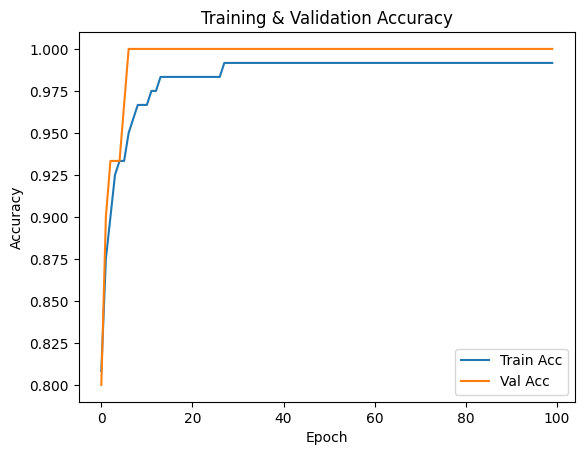

테스트 정확도: 1.000


In [6]:
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training & Validation Accuracy")
plt.show()

# ----------------------
# 6. 모델 평가
# ----------------------
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"테스트 정확도: {acc:.3f}")

   1/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step

  83/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step

 173/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step

 266/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 570us/step

 364/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step

...

 913/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step

1011/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 548us/step

1099/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step

1193/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 559us/step


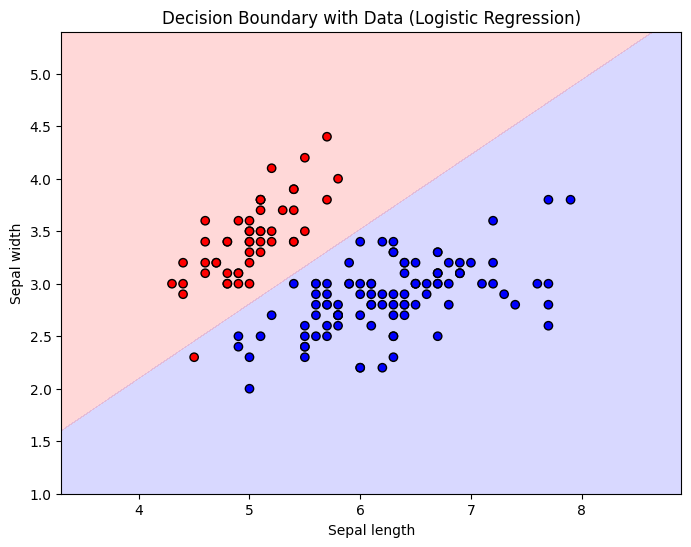

In [7]:
# ----------------------
# 결정 경계 + 전체 데이터 시각화
# ----------------------
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
grid = scaler.transform(grid)
probs = model.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))

# 결정 경계 (배경 색)
plt.contourf(xx, yy, probs, levels=[0, 0.5, 1], alpha=0.3, cmap="bwr")

# 전체 데이터 산점도 (훈련+테스트)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")

plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("Decision Boundary with Data (Logistic Regression)")
plt.show()

## 생각해보기
- 로지스틱 회귀 모델과 선형 회귀 모델의 차이는?

**답변**

**한 줄 요약 — 같은 뉴런 구조에 활성화 함수와 손실 함수만 다르다.**

강의 13p의 뉴런 식 `ŷ = f(wx + b)` 에서 **f가 항등함수면 선형 회귀, f가 sigmoid면 로지스틱 회귀**다. `wx + b`라는 선형 결합이 핵심인 것은 완전히 동일하고, 둘 다 경사하강법으로 학습한다.

| 구분 | 선형 회귀 (Linear Regression) | 로지스틱 회귀 (Logistic Regression) |
|---|---|---|
| 문제 유형 | 연속값 예측 (회귀) | **이진 분류** |
| 출력 식 | `ŷ = wx + b` | `ŷ = σ(wx + b)`, `σ(z) = 1/(1+e⁻ᶻ)` |
| 출력 범위 | (-∞, ∞) | **(0, 1) — 확률로 해석 가능** |
| 활성화 함수 | 없음 (항등) | **sigmoid** |
| 손실 함수 | MSE | **Log Loss (Binary Cross Entropy)** |
| 결과 해석 | 예측값 그 자체 | 클래스 1일 확률 → 0.5 기준으로 분류 |
| 결정 경계 | 없음 | `wx + b = 0` 인 직선(초평면) |
| 코드 차이 | `Dense(1)` | `Dense(1, activation='sigmoid')` |

**왜 로지스틱 회귀에는 MSE를 쓰지 않는가** (강의 22~23p와 연결)

1. **기울기 소실** — sigmoid는 출력이 0이나 1에 가까워지면 미분값 σ'(z)가 0에 가까워진다. MSE를 쓰면 기울기 식에 σ'(z)가 그대로 남아서, **크게 틀린 예측일수록 오히려 학습이 안 되는** 모순이 생긴다.
2. **Log Loss를 쓰면 이 항이 약분된다.** 강의 23p의 기울기 식이 `∂L/∂w = (1/N)Σ(ŷᵢ - yᵢ)x` 로 깔끔한 이유가 바로 이것이다 — sigmoid의 미분과 log의 미분이 상쇄되어, 선형 회귀(20p)와 똑같이 **"오차 × 입력"** 형태만 남는다.
3. MSE + sigmoid 조합은 손실 함수가 볼록(convex)하지 않아 국소 최소점에 빠질 수 있다.

**이번 실행 결과** — 테스트 정확도 **1.000**. Setosa는 꽃받침 길이/너비 2개 특징만으로도 다른 품종과 완전히 선형 분리가 되기 때문이며, 결정 경계 그래프에서도 직선 하나로 깨끗하게 나뉘는 것을 확인할 수 있다.

- Learning Rate(학습률)의 역할은 무엇인가요?
- 너무 크거나 너무 작은 학습률을 사용하면 어떤 일이 발생하나?

**답변**

**① 학습률의 역할 — "보폭"을 정한다**

강의 20p / 23p의 파라미터 업데이트 식에서 η가 학습률이다.

> `w ← w − η·(∂L/∂w)`,  `b ← b − η·(∂L/∂b)`

여기서 역할 분담이 명확하다.

- **기울기(∂L/∂w)** 는 *"어느 방향으로 가야 손실이 줄어드는가"* — **방향**을 알려준다.
- **학습률(η)** 은 *"그 방향으로 한 번에 얼마나 움직일 것인가"* — **보폭**을 정한다.

기울기는 현재 위치의 접선 정보일 뿐이라 **아주 조금 움직였을 때만 유효**하다. 학습률은 이 국소 정보를 얼마나 신뢰할지를 정하는 값이고, 신경망 하이퍼파라미터 중 성능에 가장 큰 영향을 주는 값이다.

**② 너무 작으면 — 수렴이 느리고, 제자리에 갇힌다**

- 정해진 epoch 안에 최적점에 도달하지 못해서, 결과만 보면 **학습이 덜 된 것(underfitting)처럼** 보인다.
- 평평한 구간(plateau)이나 얕은 국소 최소점에서 **빠져나올 힘이 없다.**
- 손실 곡선이 완만한 우하향 직선 모양으로, 끝까지 내려가고 있는 중에 학습이 끝난다.

**③ 너무 크면 — 지나치고, 심하면 발산한다**

- 최소점을 **뛰어넘어(overshoot)** 반대편 경사면에 착지하고, 이를 반복하며 골짜기를 사이에 두고 **진동**한다.
- 매 스텝마다 오차가 증폭되면 **발산(divergence)** 하고, 손실이 `NaN` 또는 `inf`가 되어 학습이 완전히 망가진다.
- 손실 곡선이 들쭉날쭉하거나 위로 치솟는 모양이면 학습률부터 의심해야 한다.

**④ 이번 3개 노트북의 설정 비교**

| 노트북 | Optimizer | Learning Rate |
|---|---|---|
| linear_regression | SGD | 0.01 |
| logistic_regression | SGD | **0.1** |
| mnist_nn_classification | **Adam** | 0.001 |

로지스틱 회귀가 10배 큰 학습률을 쓸 수 있는 이유는 `StandardScaler`로 **입력을 표준화**했기 때문이다. 특징들의 스케일이 맞춰지면 손실 함수의 등고선이 원형에 가까워져서 더 큰 보폭을 안전하게 쓸 수 있다. 반면 선형 회귀 노트북은 x가 [-5, 5], y가 수십 단위라 기울기가 커서 작은 학습률이 필요했다.

**⑤ 실무적인 대응**

- **로그 스케일로 탐색**한다: 0.0001 → 0.001 → 0.01 → 0.1 → 1. 선형적으로 훑는 것은 비효율적이다.
- **손실 곡선으로 진단**한다: 진동/발산이면 낮추고, 너무 완만하면 높인다.
- **Adam 같은 적응적 optimizer**는 파라미터마다 실효 학습률을 자동 조절해서 초기값에 덜 민감하다. MNIST 노트북이 Adam(0.001)을 쓴 이유다.
- **Learning Rate Scheduling** — 초반에는 크게 움직여 빠르게 접근하고, 후반에는 줄여서 미세 조정한다. *(4주차에서 다룸)*